In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 

from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.impute import SimpleImputer
 
from sklearn.ensemble import RandomForestRegressor

In [12]:
df = pd.read_csv("House_Prediction.csv")

# Dataset Overview

Dataset Shape: 1460 rows × 81 columns

Target Variable:
- SalePrice

Dataset contains:
- Numerical features
- Categorical features

Initial observations:
- Multiple columns contain missing values.
- House-related features include quality, area, garage, basement, age, and location information.

In [13]:
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [14]:
# df.isnull().sum().sort_values(ascending=False).head(25)

# Target Variable Analysis

Observations:

- SalePrice is right-skewed.
- Most houses fall within the lower to middle price ranges.
- Very expensive houses are rare.
- Distribution is not normal and may require transformation later.

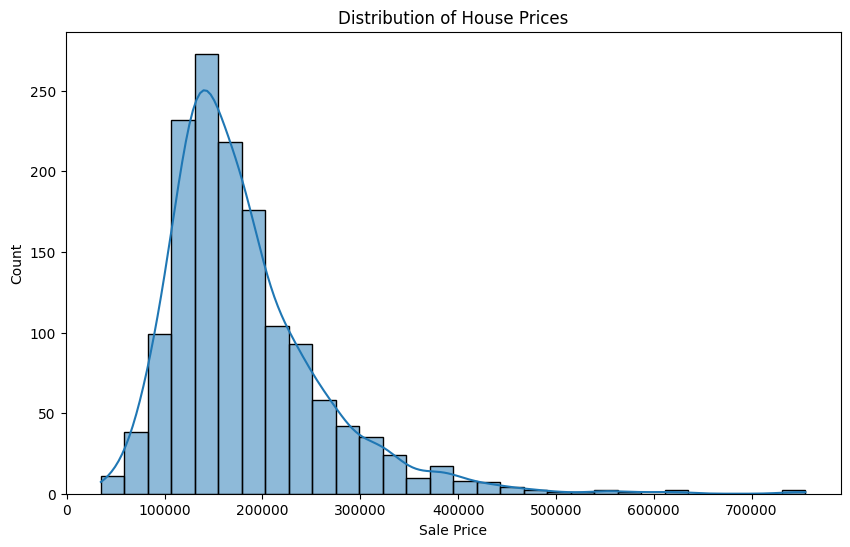

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(df["SalePrice"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Count")

plt.savefig("price_distribution.png", bbox_inches="tight", dpi=200)

plt.show()

In [16]:
# All Features of Dataset
np.array(df.columns)

array(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'GarageQual', 'GarageCond', 'Pav

# Correlation Analysis

Top Positively Correlated Features:

- OverallQual (0.79)
- GrLivArea (0.71)
- GarageCars (0.64)
- GarageArea (0.62)
- TotalBsmtSF (0.61)

Insights:

- House quality is the strongest predictor of price.
- Living area and garage-related features show strong relationships with SalePrice.
- Basement size also appears important.

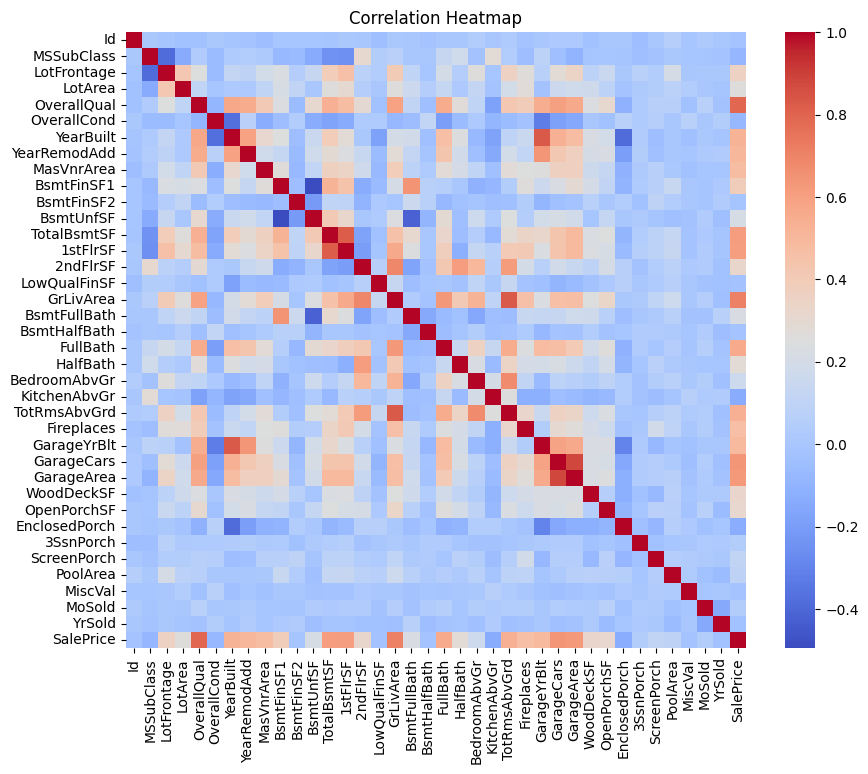

In [17]:
plt.figure(figsize=(10,8))

corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr_matrix, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("heatmap.png", bbox_inches="tight", dpi=200)

plt.show()

In [18]:
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

# Feature vs Target Analysis 
## (Highly Correlated featured) 

OverallQual vs SalePrice

- Higher quality houses generally have higher prices.
- Very few low-priced houses have high quality ratings.
- Some unusual observations exist and may be outliers.

GrLivArea vs SalePrice

- Strong positive relationship.
- Larger houses tend to have higher prices.
- A few very large houses have surprisingly low prices.

GarageCars vs SalePrice

- House prices generally increase with garage capacity.
- Houses with larger garage capacity tend to be more expensive.
- A few low-priced houses have unusually large garage capacities.

GarageArea vs SalePrice

- Larger garage areas are associated with higher house prices.
- Similar trend observed in GarageCars.
- Some potential outliers detected.

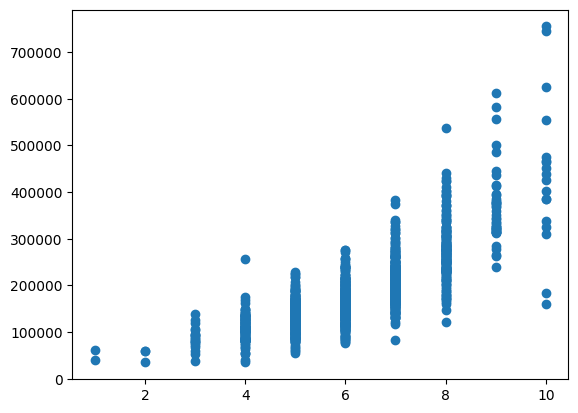

In [19]:
plt.scatter(df["OverallQual"],df["SalePrice"])
plt.show()

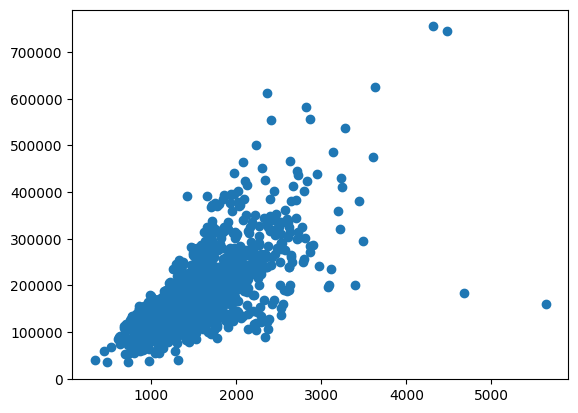

In [20]:
plt.scatter(df["GrLivArea"],df["SalePrice"])
plt.show()

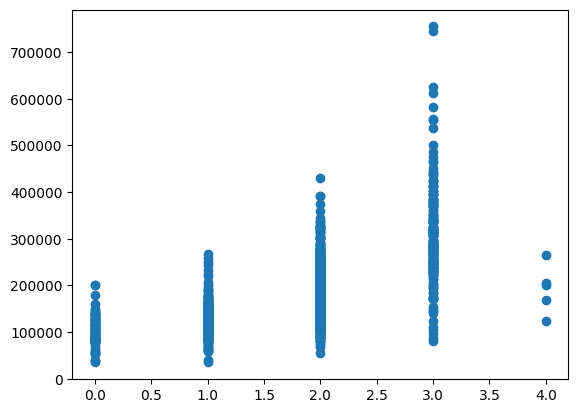

In [21]:
plt.scatter(df["GarageCars"],df["SalePrice"])
plt.show()

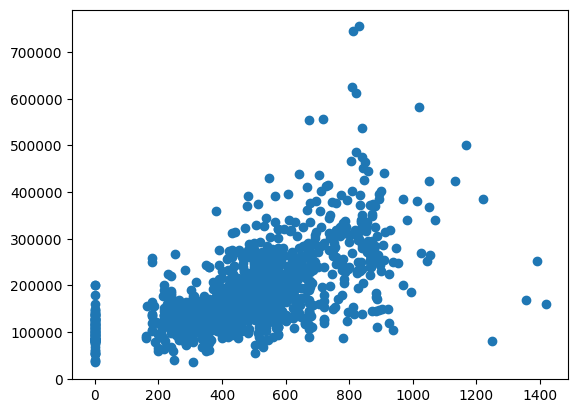

In [22]:
plt.scatter(df["GarageArea"],df["SalePrice"])
plt.show()

# Missing Value Analysis

Drop Candidates
- PoolQC
- MiscFeature
- Alley
- Fence

Missing = Feature Absent
- Garage Features → No Garage
- Basement Features → No Basement
- FireplaceQu → No Fireplace
- MasVnrType → No Masonry Veneer

Genuine Missing Values
- LotFrontage
- Electrical

In [23]:
df.isnull().sum().sort_values(ascending=False).head(25)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
BldgType           0
Neighborhood       0
LandSlope          0
LotConfig          0
Condition1         0
dtype: int64

# Missing Value Handling Plan

We will treat missing values in three steps:

1. Drop Columns,
Columns with extremely high missing values (>80%) will be dropped:
- PoolQC
- MiscFeature
- Alley
- Fence

2. Categorical Features (Missing = No Feature),
Missing values in these columns indicate absence of the feature:
- Garage features → filled with "None"
- Basement features → filled with "None"
- FireplaceQu → filled with "None"
- MasVnrType → filled with "None"

3. Numerical / Minor Missing Values,
- LotFrontage → filled with median value
- Electrical → filled with mode value

After this step, the dataset will have no missing values.

In [24]:
df = df.drop(columns = ["PoolQC", "MiscFeature", "Fence", "Alley"], axis=1)

In [25]:
columns_to_fill = ["GarageType", "GarageFinish", "GarageQual",
                   "GarageCond", "GarageYrBlt", "BsmtFinType1", 
                   "BsmtFinType2", "BsmtQual", "BsmtCond", "BsmtExposure"]
df[columns_to_fill] = df[columns_to_fill].fillna("None")

In [26]:
df["FireplaceQu"] = df["FireplaceQu"].fillna("None")

In [27]:
df["MasVnrType"] = df["MasVnrType"].fillna("None")

In [28]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [29]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [30]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

In [31]:
# Cross Check
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

# Feature Encoding

Machine learning models cannot work directly with categorical data. Therefore, categorical features will be classified into two groups:

- Ordinal Features → Ordinal Encoding
- Nominal Features → One-Hot Encoding

This transformation converts categorical values into numerical representations suitable for model training.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [33]:
cat_columns = df.select_dtypes(include=object).columns
cat_columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType',
       'SaleCondition'],
      dtype='object')

In [34]:
# checking all columns one by one 
df["LandContour"].unique()

array(['Lvl', 'Bnk', 'Low', 'HLS'], dtype=object)

In [35]:
df["GarageYrBlt"] = pd.to_numeric(df["GarageYrBlt"], errors="coerce")

In [36]:
ordinal_columns = [ "LotShape", "LandSlope", "ExterCond", "ExterQual", "BsmtQual", 
                   "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
                   "HeatingQC", "KitchenQual", "Functional", "FireplaceQu", 
                   "GarageFinish" ,"GarageQual", "GarageCond", "PavedDrive"
]

In [37]:
nominal_columns = [ "MSZoning", "Street", "Utilities", "LotConfig", "Neighborhood", 
                   "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", 
                   "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation",
                   "Heating", "CentralAir", "Electrical", "GarageType", "LandContour",
                   "SaleType", "SaleCondition"
    
]

In [38]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [39]:
numeric_columns.remove("SalePrice")

In [40]:
numeric_columns

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [41]:
preprocessor = ColumnTransformer(transformers=[
    ("ord", OrdinalEncoder(), ordinal_columns),   
    ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_columns),
    ("num", SimpleImputer(strategy="median"), numeric_columns)
])

# Model Training (Linear Regression)

After completing feature encoding, the dataset is now ready for machine learning model training.

In this step, we will:
- Split the dataset into training and testing sets
- Train a baseline regression model (Linear Regression)
- Evaluate model performance using R² score

In [42]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

In [44]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [45]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ord', ...), ('nom', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
y_pred = model.predict(X_test)

In [47]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.8794761979330727


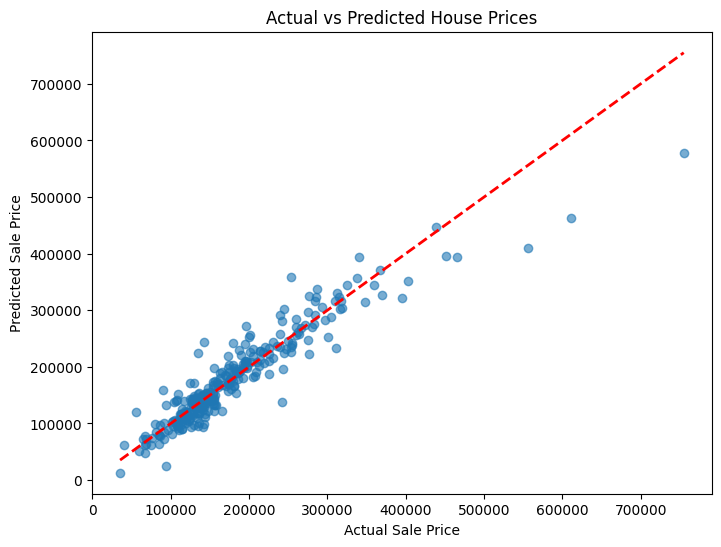

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png", bbox_inches="tight", dpi=200)

plt.show()

# Model Training (Random Forest)

To improve model performance, we are now training a more powerful ensemble model: Random Forest Regressor.

This model is used to capture non-linear relationships in the data, which Linear Regression may not fully learn.

In [49]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [50]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ord', ...), ('nom', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
y_pred_rf = rf_model.predict(X_test)

In [52]:
rf_r2 = r2_score(y_test, y_pred_rf)
print(rf_r2)

0.8903157582482247


# Model Comparison

Two regression models were trained and evaluated:

- Linear Regression → R² ≈ 0.87  
- Random Forest Regressor → R² ≈ 0.89  

Random Forest performed slightly better, indicating its ability to capture non-linear relationships in the dataset.

In [53]:
print(r2)
print(rf_r2)

0.8794761979330727
0.8903157582482247


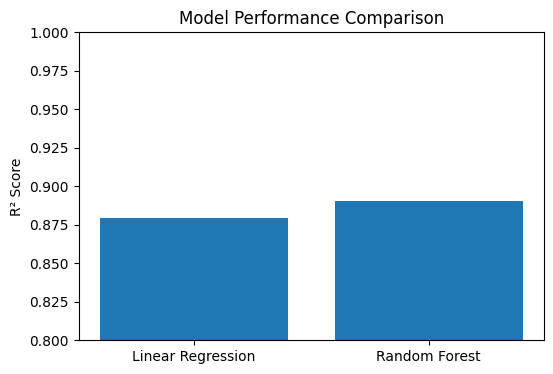

In [55]:
models = ["Linear Regression", "Random Forest"]
scores = [r2, rf_r2]

plt.figure(figsize=(6,4))

plt.bar(models, scores)

plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.ylim(0.8, 1.0)

plt.savefig("model_comparison.png", bbox_inches="tight", dpi=200)

plt.show()

# Key Insights

- The dataset showed a strong relationship between house features and SalePrice, especially OverallQual, GrLivArea, and Garage-related features.

- Careful handling of missing values improved data quality significantly. Structural missing values (like no garage or no fireplace) were handled separately from numeric missing values.

- Feature engineering and proper encoding (Ordinal + One-Hot) played a major role in improving model performance.

- Even a simple Linear Regression model performed strongly, showing that the dataset has mostly linear patterns.

- Random Forest slightly improved performance, indicating the presence of some non-linear relationships between features and target variable.

- Overall, good preprocessing had a bigger impact than model complexity in this project.

# Conclusion

This project demonstrates how proper data preprocessing and feature engineering can significantly improve model performance. Even simple models performed well due to strong data relationships.